
--- 1.1 Inspección inmediata después de cargar el CSV ---
Columnas: Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'condition'],
      dtype='object')
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   69    1   0       160   234    1        2      131      0      0.1      1   
1   69    0   0       140   239    0        0      151      0      1.8      0   
2   66    0   0       150   226    0        0      114      0      2.6      2   
3   65    1   0       138   282    1        2      174      0      1.4      1   
4   64    1   0       110   211    0        2      144      1      1.8      1   

   ca  thal  condition  
0   1     0          0  
1   2     0          0  
2   0     0          0  
3   1     0          1  
4   0     0          0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Co

<Figure size 800x600 with 0 Axes>

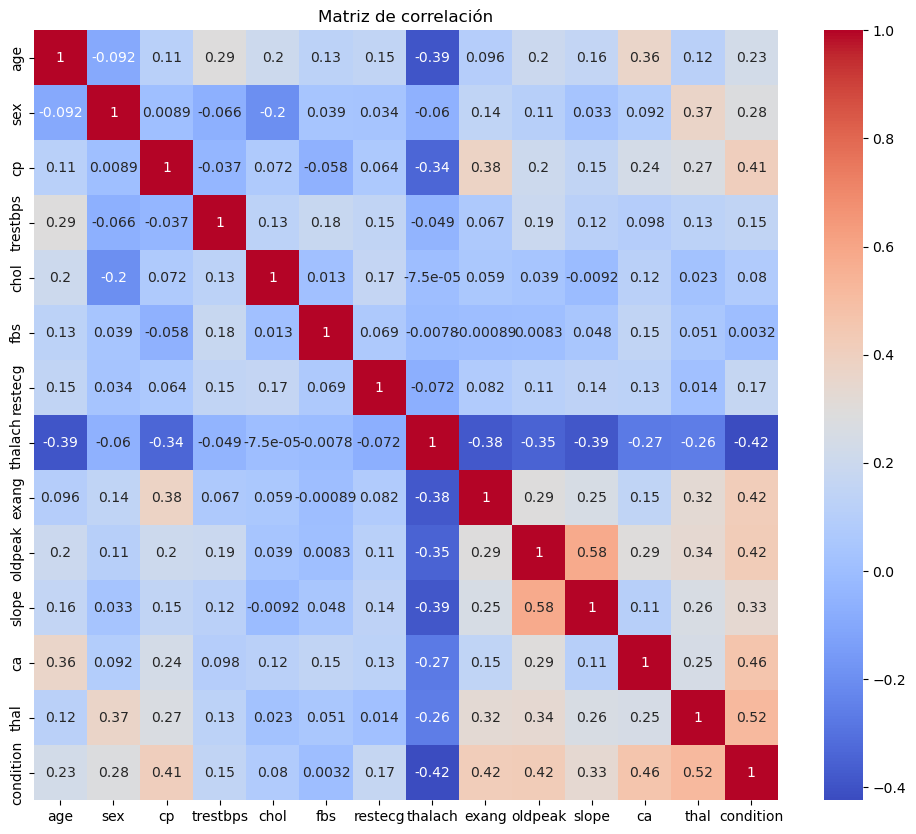


--- 3.0 Verificación antes de dropna() ---
Error: La columna 'target' no está presente antes de dropna().
Columnas: Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'condition'],
      dtype='object')
Error durante el preprocesamiento. No se puede continuar.

--- 4.0 Verificación justo antes de la división ---
Error: DataFrame es None antes de la división.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score
import os

def preprocess_data(df):
    """
    Realiza el preprocesamiento del DataFrame.

    Args:
        df (pd.DataFrame): El DataFrame original.

    Returns:
        pd.DataFrame: El DataFrame preprocesado.
    """

    # 3.0 Verificación antes de dropna()
    print("\n--- 3.0 Verificación antes de dropna() ---")
    if 'target' not in df.columns:
        print("Error: La columna 'target' no está presente antes de dropna().")
        print("Columnas:", df.columns)
        return None  # Devolvemos None para indicar fallo

    df = df.dropna()

    # 3.1 Verificación después de dropna()
    print("\n--- 3.1 Verificación después de dropna() ---")
    if 'target' not in df.columns:
        print("Error: La columna 'target' no está presente después de dropna().")
        print("Columnas:", df.columns)
        return None

    categorical_cols = [col for col in df.columns if df[col].dtype == 'object']

    # 3.2 Verificación antes de One-Hot Encoding
    print("\n--- 3.2 Verificación antes de One-Hot Encoding ---")
    if 'target' not in df.columns:
        print("Error: La columna 'target' no está presente antes de One-Hot Encoding.")
        print("Columnas:", df.columns)
        return None

    if categorical_cols:
        df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
        df = df.reset_index(drop=True)

    # 3.3 Verificación después de One-Hot Encoding
    print("\n--- 3.3 Verificación después de One-Hot Encoding ---")
    if 'target' not in df.columns:
        print("Error: La columna 'target' no está presente después de One-Hot Encoding.")
        print("Columnas:", df.columns)
        return None

    return df

# 1. Cargar el dataset
file_path = os.path.join('regresionlogistica', 'heart_cleveland_upload.csv')

# Verificar si el archivo existe
if not os.path.exists(file_path):
    print(f"Error: No se encontró el archivo {file_path}. Verifica la ruta y el nombre del archivo.")
    exit()

try:
    df = pd.read_csv(file_path, encoding='utf-8', header=0)  # **Carga del CSV modificada**
except Exception as e:
    print(f"Ocurrió un error al cargar el archivo: {e}")
    exit()

# 1.1 Verificación inmediata después de cargar el CSV
print("\n--- 1.1 Inspección inmediata después de cargar el CSV ---")
print("Columnas:", df.columns)
print(df.head())
print(df.info())

# 2. Análisis Exploratorio de Datos (EDA)
print("\n--- 2. Análisis Exploratorio de Datos (EDA) ---")
print("\nPrimeras filas del dataset:")
print(df.head())
print("\nInformación del dataset:")
print(df.info())
print("\nDescripción estadística del dataset:")
print(df.describe())

# 2.1 Verificación antes de la visualización
print("\n--- 2.1 Verificación antes de la visualización ---")
if 'target' not in df.columns:
    print("Error: La columna 'target' no está presente antes de la visualización.")
    print("Columnas:", df.columns)
    exit()

# Visualización
plt.figure(figsize=(8, 6))
try:
    sns.countplot(x='target', data=df)
    plt.title('Distribución de la variable objetivo (target)')
    plt.show()
except ValueError as e:
    print(f"Error al graficar: {e}")

plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

# 3. Preprocesamiento de los datos
df = preprocess_data(df.copy())  # Pasamos una copia para seguridad

if df is None:
    print("Error durante el preprocesamiento. No se puede continuar.")
    exit()

# Escalar las características
scaler = StandardScaler()

# 4.0 Verificación justo antes de la división y todo el modelado dentro del if
print("\n--- 4.0 Verificación justo antes de la división ---")
if df is not None:
    if 'target' not in df.columns:
        print("Error: La columna 'target' no está presente antes de la división.")
        print("Columnas:", df.columns)
        exit()
    X = df.drop('target', axis=1, errors='ignore')
    y = df['target']

    # Manejar el caso donde no hay columnas numéricas
    if X.empty:
        print("Error: No hay columnas de características después del preprocesamiento.")
        exit()

    X_scaled = scaler.fit_transform(X)

    # 4. Dividir el dataset en Train y Test
    print("\n--- 4. Dividir el dataset en Train y Test ---")
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

    # 5. Entrenar el modelo
    print("\n--- 5. Entrenar el modelo ---")
    # Usar GridSearch para encontrar los mejores hiperparámetros
    param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}
    grid_search = GridSearchCV(LogisticRegression(max_iter=10000), param_grid, cv=5, scoring='accuracy')
    grid_search.fit(X_train, y_train)

    print("Mejores hiperparámetros:", grid_search.best_params_)
    best_model = grid_search.best_estimator_

    # 6. Evaluar el desempeño del modelo
    print("\n--- 6. Evaluar el desempeño del modelo ---")
    y_pred = best_model.predict(X_test)

    print("\nMatriz de Confusión:")
    print(confusion_matrix(y_test, y_pred))

    print("\nInforme de Clasificación:")
    print(classification_report(y_test, y_pred))

    # Curva ROC y AUC
    y_pred_proba = best_model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    auc = roc_auc_score(y_test, y_pred_proba)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos')
    plt.title('Curva ROC')
    plt.legend()
    plt.show()

    # 7. Visualizar los resultados (ya se visualizaron en el paso 6)

    # 8. Interpretar, analizar y documentar los resultados obtenidos
    print("\n--- 8. Interpretar, analizar y documentar los resultados obtenidos ---")
    print("\nInterpretación:")
    print("El modelo de Regresión Logística se entrenó y evaluó.")
    print("La Matriz de Confusión muestra el número de predicciones correctas e incorrectas por clase.")
    print("El Informe de Clasificación proporciona métricas como Precisión, Recall y F1-score para cada clase.")
    print("La Curva ROC y el valor AUC indican la capacidad del modelo para distinguir entre las clases.")

else:
    print("Error: DataFrame es None antes de la división.")
    exit()